<a href="https://colab.research.google.com/github/MohammadJoenathan/Klasifikasi-Instrumen-Gamelan-Jawa-CNN-Mobilenetv2/blob/main/KlasifikasiJenisInstrumenGamelanJawaMenggunakan_CNN_dengan_Arsitektur_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Menghubungkan Google Colab dengan Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2. Install Library yang Dibutuhkan

In [6]:
!pip install tensorflow matplotlib seaborn scikit-learn

#3. Import Library

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


#4. Menentukan Lokasi Dataset

In [8]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/Gamelan"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"

#5. Mengecek Jumlah Data Setiap Kelas

In [9]:
print("=== DATA TRAIN ===")

for kelas in os.listdir(train_path):
    jumlah = len(os.listdir(os.path.join(train_path, kelas)))
    print(f"{kelas} : {jumlah}")

print("\n=== DATA VALID ===")

for kelas in os.listdir(valid_path):
    jumlah = len(os.listdir(os.path.join(valid_path, kelas)))
    print(f"{kelas} : {jumlah}")

=== DATA TRAIN ===
bonang : 180
gambang : 237
gender : 129
gong : 84
kempul : 207
kendhang : 234
kenong : 240
rebab : 132
saron : 192
suling : 165

=== DATA VALID ===
kenong : 20
gong : 7
rebab : 10
gender : 9
kempul : 17
saron : 16
bonang : 15
suling : 13
gambang : 21
kendhang : 20


#6. Data Augmentation dan Preprocessing

In [10]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1800 images belonging to 10 classes.
Found 148 images belonging to 10 classes.


#7. Menampilkan Contoh Citra Dataset

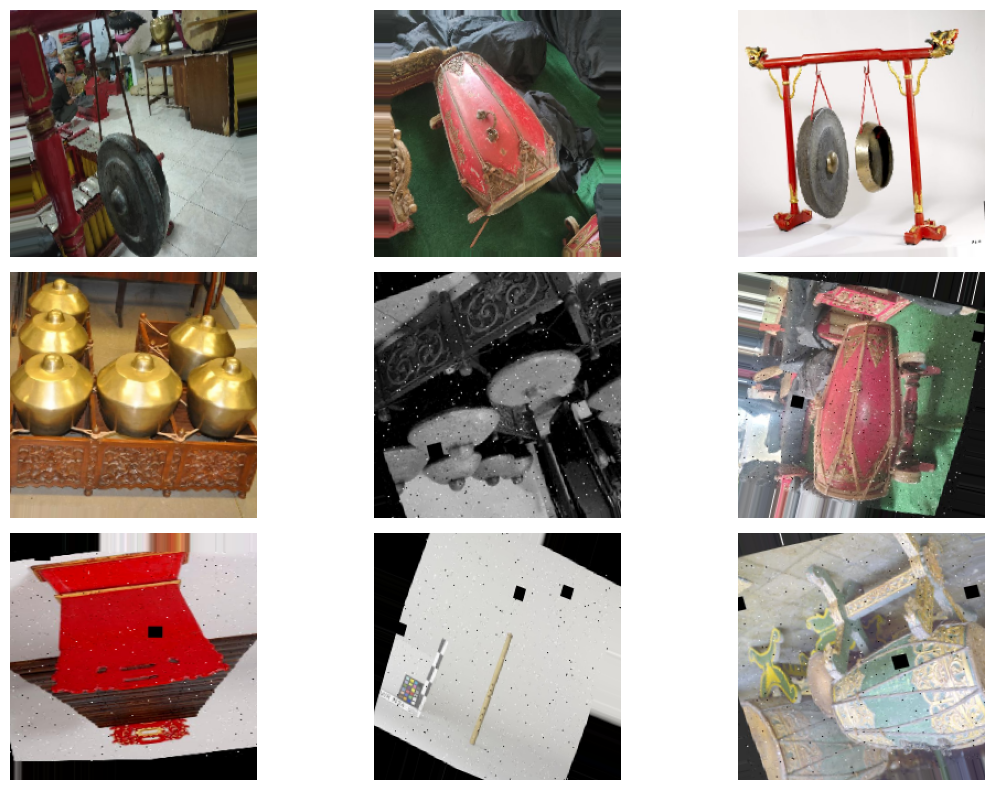

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

#8. Membangun Model MobileNetV2

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

#9. Menambahkan Layer Klasifikasi

In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#10. Compile Model

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#11. Training Model

In [15]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 272s 5s/step - accuracy: 0.2967 - loss: 2.1388 - val_accuracy: 0.6757 - val_loss: 1.2571
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5706 - loss: 1.3140 - val_accuracy: 0.8446 - val_loss: 0.7799
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6944 - loss: 0.9524 - val_accuracy: 0.8986 - val_loss: 0.5397
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7828 - loss: 0.7228 - val_accuracy: 0.9054 - val_loss: 0.4264
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8111 - loss: 0.6039 - val_accuracy: 0.9189 - val_loss: 0.3442
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8461 - loss: 0.5287 - val_accuracy: 0.9257 - val_loss: 0.3015
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8633 - loss: 0.4564 - val_accuracy: 0.9324 - val_loss: 0.2626
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8800 - loss: 0.4038 - val_accuracy: 0.9392 - val_loss

#12. Menampilkan Grafik Akurasi

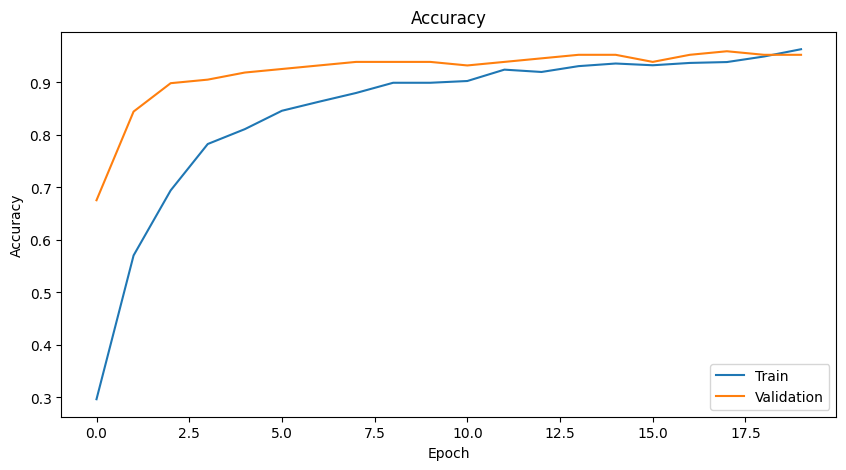

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])
plt.show()

#13. Menampilkan Grafik Loss

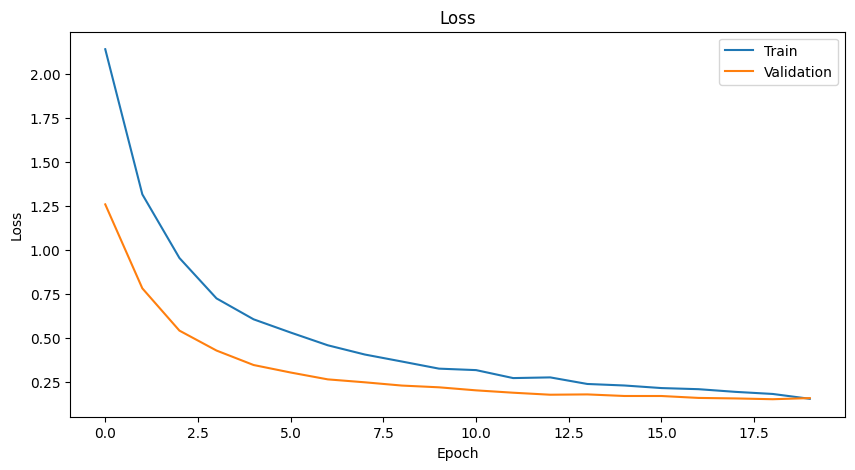

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])
plt.show()

#14. Evaluasi Model

In [18]:
loss, acc = model.evaluate(valid_generator)

print("Loss :", loss)
print("Accuracy :", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9527 - loss: 0.1562
Loss : 0.15616154670715332
Accuracy : 0.9527027010917664


#15. Menyiapkan Data Evaluasi

In [19]:
pred = model.predict(valid_generator)

pred_class = np.argmax(pred, axis=1)

true_class = valid_generator.classes

class_names = list(valid_generator.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


#16. Classification Report

In [20]:
print(
    classification_report(
        true_class,
        pred_class,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      bonang       1.00      1.00      1.00        15
     gambang       0.95      0.90      0.93        21
      gender       1.00      1.00      1.00         9
        gong       1.00      0.71      0.83         7
      kempul       0.85      1.00      0.92        17
    kendhang       0.95      1.00      0.98        20
      kenong       1.00      0.95      0.97        20
       rebab       1.00      0.90      0.95        10
       saron       0.88      0.94      0.91        16
      suling       1.00      1.00      1.00        13

    accuracy                           0.95       148
   macro avg       0.96      0.94      0.95       148
weighted avg       0.96      0.95      0.95       148



#17. Confusion Matrix

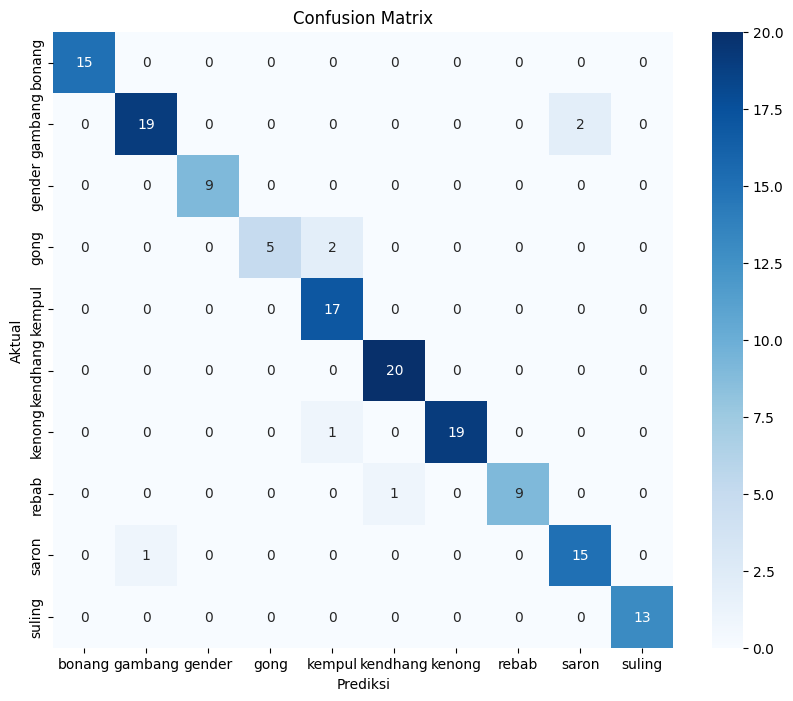

In [21]:
cm = confusion_matrix(
    true_class,
    pred_class
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")

plt.show()